In [174]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import string
import math
import re

from transformers import BertTokenizer, BertModel
import torch.nn.functional as F
import torch

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import FunctionTransformer

In [175]:
root_path = "/home/stefan/ioai-prep/kits/textual_similarity_oracle"

seed = 42

# Data

In [176]:
df = pd.read_csv(f"{root_path}/test.csv")
submission = df[["sampleID"]]

df.head()

,sampleID,sentence1,sentence2
0,5749,A girl is styling her hair.,A girl is brushing her hair.
1,5750,A group of men play soccer on the beach.,A group of boys are playing soccer on the beach.
2,5751,One woman is measuring another woman's ankle.,A woman measures another woman's ankle.
3,5752,A man is cutting up a cucumber.,A man is slicing a cucumber.
4,5753,A man is playing a harp.,A man is playing a keyboard.


# Subtask 1

In [177]:
tok = lambda u: [t for t in u.split(" ") if t not in string.punctuation]

In [178]:
df["avg_len"] = df.apply(
    lambda r: math.floor((len(r["sentence1"]) + len(r["sentence2"])) / 2), axis=1
)

def len2word(l):
    return "Short"
    # medium - 2%
    # short - 6%
    # long - 2%
    if l < 20:
        return "Short"
    if l < 50:
        return "Medium"
    return "Long"

subtask1 = df["avg_len"].map(len2word)

subtask1.head()

0    Short
1    Short
2    Short
3    Short
4    Short
Name: avg_len, dtype: object

<Axes: >

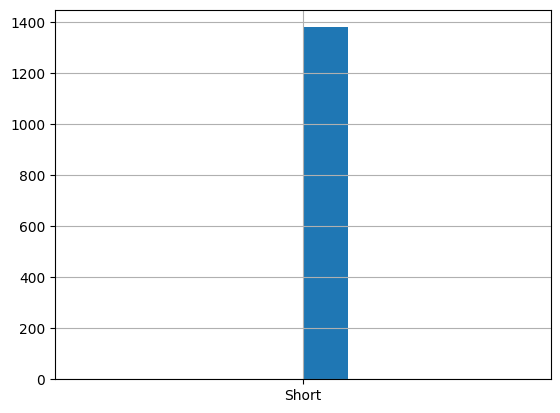

In [179]:
subtask1.hist()

# Subtask 2

In [180]:
tok = lambda u: [
    t
    for t in re.split(r"[ ]+", u)
    if (t not in ".!?'\"-$:") or (not any(ch.isdigit() for ch in t))
]

In [181]:
tok(df.iloc[44]["sentence1"])

['A', 'man', 'is', 'cutting', 'apple', 'by', 'his', 'hand.']

In [182]:
subtask2 = df.apply(
    lambda r: len(tok(r["sentence1"])) + len(tok(r["sentence2"])),
    axis=1,
)

subtask2.head()

0    12
1    19
2    13
3    13
4    12
dtype: int64

<Axes: >

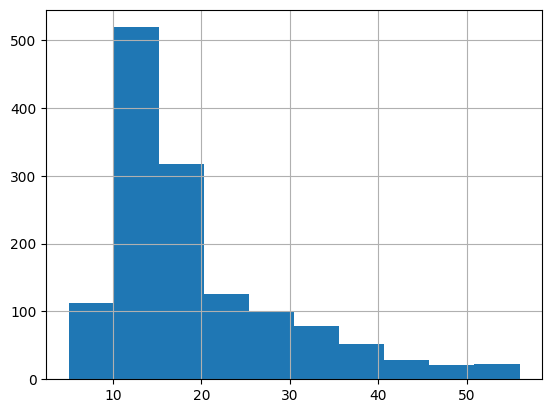

In [183]:
subtask2.hist()

# Subtask 3

In [184]:
subtask3 = df.apply(
    lambda r: abs(len(r["sentence1"]) - len(r["sentence2"])),
    axis=1,
)

subtask2.head()

0    12
1    19
2    13
3    13
4    12
dtype: int64

# Subtask 4

In [185]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased").to("cuda")

In [270]:
def add_embeddings(df: pd.DataFrame, batch_size: int = 256) -> pd.DataFrame:
    model.eval()
    sims = []

    for i in tqdm(range(0, len(df), batch_size)):
        slc = df.iloc[i : i + batch_size]
        s1 = tokenizer(slc["sentence1"].tolist(), padding=True, truncation=True, return_tensors="pt").to("cuda")
        s2 = tokenizer(slc["sentence2"].tolist(), padding=True, truncation=True, return_tensors="pt").to("cuda")

        with torch.no_grad():
            out1 = model(**s1).pooler_output
            out2 = model(**s2).pooler_output
        sims.append(F.cosine_similarity(out1, out2).cpu())

    df["bert_sim"] = torch.cat(sims).numpy()
    return df

In [ ]:
pt = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)

def prep_df(df: pd.DataFrame) -> pd.DataFrame:
    if "score" in df:
        y = df["score"]
    else:
        y = None
    df = df.drop(["sampleID", "score", "avg_len", "sim"], axis=1, errors="ignore")

    df = add_embeddings(df)
    df["bert_sim"] = pt.fit_transform(df[["bert_sim"]])

    # length features
    df["len1"] = df["sentence1"].str.len()
    df["len2"] = df["sentence2"].str.len()
    df["diff_len"] = (df["len1"] - df["len2"]).abs()

    # word-count features
    df["words1"] = df["sentence1"].apply(lambda s: len(s.split()))
    df["words2"] = df["sentence2"].apply(lambda s: len(s.split()))
    df["total_words"] = df["words1"] + df["words2"]

    df = df.select_dtypes(include='number')

    if y is not None:
        return df, y
    return df

In [311]:
df_train = pd.read_csv(f"{root_path}/train.csv")
df_train, y = prep_df(df_train)

df_train.head()

100%|██████████| 23/23 [00:06<00:00,  3.43it/s]


,bert_sim,len1,len2,diff_len,words1,words2,total_words
0,0.999792,22,27,5,5,6,11
1,0.998462,31,25,6,7,6,13
2,0.998863,45,56,11,9,10,19
3,0.999451,28,26,2,5,5,10
4,0.997932,27,34,7,6,7,13


In [312]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train, y, test_size=0.2, random_state=seed
)

In [313]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, cv=3, n_jobs=-1)
    cv = cv.mean() + cv.std()
    return cv

In [314]:
ridge = Ridge(alpha=1000)
evaluate(ridge)

np.float64(0.054755706100827015)

In [321]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor()
evaluate(cb)

Learning rate set to 0.048872
0:	learn: 1.4474917	total: 50.8ms	remaining: 50.7s
1:	learn: 1.4425996	total: 51.6ms	remaining: 25.8s
2:	learn: 1.4376454	total: 54.2ms	remaining: 18s
3:	learn: 1.4333916	total: 55.6ms	remaining: 13.8s
4:	learn: 1.4295095	total: 56.4ms	remaining: 11.2s
5:	learn: 1.4260582	total: 57.4ms	remaining: 9.51s
6:	learn: 1.4225449	total: 58.2ms	remaining: 8.26s
7:	learn: 1.4195691	total: 60.1ms	remaining: 7.45s
8:	learn: 1.4172965	total: 61ms	remaining: 6.72s
9:	learn: 1.4141073	total: 61.8ms	remaining: 6.12s
10:	learn: 1.4115081	total: 62.6ms	remaining: 5.63s
11:	learn: 1.4085363	total: 63.4ms	remaining: 5.22s
12:	learn: 1.4056140	total: 67.9ms	remaining: 5.15s
Learning rate set to 0.048872
Learning rate set to 0.048872
13:	learn: 1.4034912	total: 71.8ms	remaining: 5.05s
14:	learn: 1.4015722	total: 75.4ms	remaining: 4.95s
15:	learn: 1.3994700	total: 76.3ms	remaining: 4.69s
16:	learn: 1.3980144	total: 77.9ms	remaining: 4.5s
17:	learn: 1.3965816	total: 78.9ms	remain

np.float64(0.05184722893397106)

In [322]:
model_score = cb
model_score.fit(X_train, y_train)

Learning rate set to 0.052105
0:	learn: 1.4549510	total: 46.7ms	remaining: 46.7s
1:	learn: 1.4504670	total: 47.7ms	remaining: 23.8s
2:	learn: 1.4461834	total: 48.6ms	remaining: 16.1s
3:	learn: 1.4417208	total: 49.6ms	remaining: 12.3s
4:	learn: 1.4379558	total: 50.5ms	remaining: 10s
5:	learn: 1.4343451	total: 51.9ms	remaining: 8.6s
6:	learn: 1.4311021	total: 53.1ms	remaining: 7.54s
7:	learn: 1.4282811	total: 54ms	remaining: 6.69s
8:	learn: 1.4261254	total: 55ms	remaining: 6.06s
9:	learn: 1.4236510	total: 56.2ms	remaining: 5.56s
10:	learn: 1.4209786	total: 57.6ms	remaining: 5.18s
11:	learn: 1.4186198	total: 60.2ms	remaining: 4.95s
12:	learn: 1.4159877	total: 61.4ms	remaining: 4.67s
13:	learn: 1.4139644	total: 62.4ms	remaining: 4.4s
14:	learn: 1.4122521	total: 63.8ms	remaining: 4.19s
15:	learn: 1.4105252	total: 65.2ms	remaining: 4.01s
16:	learn: 1.4089778	total: 66.5ms	remaining: 3.84s
17:	learn: 1.4073324	total: 67.7ms	remaining: 3.69s
18:	learn: 1.4056650	total: 69ms	remaining: 3.56s
19

In [323]:
df_test = prep_df(df)

100%|██████████| 6/6 [00:01<00:00,  3.73it/s]


In [324]:
subtask4 = model_score.predict(df_test)

# subtask4 = np.full_like(subtask3, 2.5)
subtask4.mean()

np.float64(2.6122038419988467)

# Submission

In [325]:
subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3),
    (4, subtask4),
]

In [326]:
def build_subtask(sid, answer):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": df["sampleID"],
        "answer": answer
    })

submission = pd.concat([build_subtask(sid, ans) for sid, ans in subtasks])
submission.head()

,subtaskID,datapointID,answer
0,1,5749,Short
1,1,5750,Short
2,1,5751,Short
3,1,5752,Short
4,1,5753,Short


In [327]:
submission.to_csv(f"{root_path}/submission.csv", index=False)